 **Task 1**

In [ ]:
import torch
import torch.nn.functional as F
import os, urllib.request

In [ ]:

# 1) names datasetini yükle
if not os.path.exists('names.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/karpathy/makemore/master/names.txt', 'names.txt')

words = open('names.txt', 'r').read().splitlines()
print(words[:8])
print('toplam isim:', len(words))          # 32033

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
toplam isim: 32033


In [ ]:
# 2-3) vocabulary ve karakter <-> index eşlemeleri
# Videodaki gibi karakterleri veriden türetiyoruz (elle "a".."z" yazmak yerine);
# sonuç aynı: "." -> 0, "a" -> 1, ..., "z" -> 26
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)
print('vocab boyutu:', len(stoi))          # 27

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab boyutu: 27


In [ ]:
# 4-7) veri setini kur
block_size = 3   # bağlam uzunluğu: kaç harfe bakarak bir sonrakini tahmin ediyoruz

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size            # "..." ile başla
        for ch in w + '.':                    # kelimenin sonuna "." ekle
            ix = stoi[ch]
            X.append(context)                 # girdi: mevcut bağlam
            Y.append(ix)                      # hedef: sıradaki harf
            # print(''.join(itos[i] for i in context), '--->', itos[ix])   # örnekleri görmek için aç
            context = context[1:] + [ix]      # sola kaydır, yeni harfi sona ekle
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

# Videodaki gibi önce ilk 5 kelimeyle ne ürettiğimize bakalım
X, Y = build_dataset(words[:5])
print(X.shape, X.dtype, Y.shape, Y.dtype)   # (32, 3) int64, (32,) int64

# Tüm veri seti
X, Y = build_dataset(words)
print(X.shape, Y.shape)                     # (228146, 3) (228146,)
print(X[:5]); print(Y[:5])




torch.Size([32, 3]) torch.int64 torch.Size([32]) torch.int64
torch.Size([228146, 3]) torch.Size([228146])
tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]])
tensor([ 5, 13, 13,  1,  0])


In [ ]:
# 8) embedding tablosu: 27 karakter x 2 boyut, rastgele başlatılır, eğitimde öğrenilecek
C = torch.randn((27, 2))
print(C.shape)

torch.Size([27, 2])


In [ ]:
# 9) indeksleme ile embedding çekme — videodaki adımlar
# tek bir integer
print(C[5])
# one-hot ile aynı sonuç (one-hot @ C sadece 5. satırı "seçer"); dtype float'a çevirmek gerekiyor
print(F.one_hot(torch.tensor(5), num_classes=27).float() @ C)
# liste / tensor ile birden fazla satır (tekrar eden indexler dahil)
print(C[[5, 6, 7, 7, 7]].shape)
print(C[torch.tensor([5, 6, 7])].shape)


tensor([-0.8680, -0.1009])
tensor([-0.8680, -0.1009])
torch.Size([5, 2])
torch.Size([3, 2])


In [ ]:
# 9-10) X'in tamamı için tek seferde lookup: çok boyutlu tensor ile indexleme
emb = C[X]
print(emb.shape)                            # (N, 3, 2)

# doğrulama: emb[13, 2] == C[X[13, 2]]
print(X[13, 2].item(), emb[13, 2], C[X[13, 2]])
assert torch.equal(emb[13, 2], C[X[13, 2]])

torch.Size([228146, 3, 2])
1 tensor([ 1.7313, -1.2598]) tensor([ 1.7313, -1.2598])


**Task 2**

In [ ]:
X, Y = build_dataset(words[:5])
N = X.shape[0]                              # 32

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# 1) Task 1'den gelen embedding lookup
emb = C[X]
print(emb.shape)                            # (N, 3, 2)

torch.Size([32, 3, 2])


In [ ]:
# 2) düzleştirme: (N, 3, 2) -> (N, 6)
# Videodaki "yanlış ama çalışan" yol: her harfin embedding'ini ayrı çekip yan yana yapıştır
emb_cat = torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)
# block_size'a bağlı kalmayan hali:
emb_cat = torch.cat(torch.unbind(emb, dim=1), dim=1)
print(emb_cat.shape)                        # (N, 6)

# Doğru yol: .view — bellek kopyalamaz, sadece shape/stride bilgisini değiştirir (cat yeni tensor üretir)
emb_flat = emb.view(-1, block_size * C.shape[1])   # -1: N'i PyTorch kendisi çıkarsın
print(emb_flat.shape)                       # (N, 6)
print(torch.equal(emb_cat, emb_flat))       # True -> aynı sonuç, view çok daha ucuz

torch.Size([32, 6])
torch.Size([32, 6])
True


In [ ]:
# 3-5) gizli katman (100 nöron: hyperparameter, sonra büyüteceğiz)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)

hidden_pre_activation = emb_flat @ W1 + b1  # (N,6) @ (6,100) -> (N,100); b1 (100,) satırlara broadcast edilir
h = torch.tanh(hidden_pre_activation)       # -1..1 aralığına sıkıştır
print(h.shape)                              # (N, 100)

print(hidden_pre_activation.shape, b1.shape)

torch.Size([32, 100])
torch.Size([32, 100]) torch.Size([100])


In [ ]:
# 6-7) çıkış katmanı: 27 karakter için ham skorlar (logits)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

logits = h @ W2 + b2                        # (N,100) @ (100,27) -> (N,27)
print(logits.shape)

torch.Size([32, 27])


In [ ]:
#8) LOSS'U ELLE HESAPLA (Part 1 ile aynı yol)
counts = logits.exp()                                   # a) "sahte sayımlar"
probs = counts / counts.sum(dim=1, keepdim=True)        # b) satır bazında normalize -> her satır 1'e toplanır
print(probs.shape, probs[0].sum())                      # (N, 27), tensor(1.)

correct_probs = probs[torch.arange(N), Y]               # c) her örnek için doğru harfe verilen olasılık
print(correct_probs)                                    #    eğitilmemiş ağ: bazıları çok küçük

individual_losses = -correct_probs.log()                # d) negatif log-olasılık
manual_loss = individual_losses.mean()                  # e) ortalama
print('manual loss:', manual_loss.item())               # video: ~17 (rastgele başlangıç)


torch.Size([32, 27]) tensor(1.)
tensor([1.5213e-14, 1.2830e-12, 1.9647e-08, 3.1758e-10, 5.6763e-12, 1.0823e-10,
        1.8821e-14, 1.1087e-08, 1.6134e-09, 2.1917e-03, 5.3863e-08, 3.1970e-04,
        2.0283e-10, 3.5709e-11, 6.2336e-07, 5.1704e-07, 1.4206e-01, 9.5657e-09,
        2.0670e-09, 2.5181e-02, 7.6846e-05, 2.8706e-12, 1.6961e-09, 5.6464e-15,
        4.4656e-03, 2.6851e-09, 3.5864e-05, 2.3389e-04, 1.6890e-09, 9.5614e-01,
        9.7404e-10, 2.1230e-12])
manual loss: 17.769710540771484


In [ ]:
# 9-10) aynı şeyi PyTorch ile
cross_entropy_loss = F.cross_entropy(logits, Y)
print('F.cross_entropy:', cross_entropy_loss.item())
print(torch.allclose(manual_loss, cross_entropy_loss))  # True

F.cross_entropy: 17.76971435546875
True


In [ ]:
def manual_softmax(logits):
    counts = logits.exp()
    return counts / counts.sum()

print(manual_softmax(torch.tensor([-2., 3., 0., 5.])))     # normal: sorun yok
print(manual_softmax(torch.tensor([-100., 3., 0., 5.])))   # çok negatif: exp -> ~0, yine sorun yok
print(manual_softmax(torch.tensor([100., 3., 0., 5.])))    # çok pozitif: exp(100) = inf -> nan

# softmax offset'e duyarsız: aynı olasılıklar
l = torch.tensor([-2., 3., 0., 5.])
print(manual_softmax(l), manual_softmax(l + 1), manual_softmax(l - 3))

# PyTorch'un yaptığı: max'ı çıkar, sonra exp
l = torch.tensor([100., 3., 0., 5.])
print(manual_softmax(l - l.max()))                         # artık nan yok
print(F.softmax(l, dim=0))

tensor([7.9781e-04, 1.1841e-01, 5.8950e-03, 8.7490e-01])
tensor([0.0000, 0.1185, 0.0059, 0.8756])
tensor([nan, 0., 0., 0.])
tensor([7.9781e-04, 1.1841e-01, 5.8950e-03, 8.7490e-01]) tensor([7.9781e-04, 1.1841e-01, 5.8950e-03, 8.7490e-01]) tensor([7.9781e-04, 1.1841e-01, 5.8950e-03, 8.7490e-01])
tensor([1.0000e+00, 7.4689e-43, 3.7835e-44, 5.5211e-42])
tensor([1.0000e+00, 7.4689e-43, 3.7835e-44, 5.5211e-42])


**Task 3**

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# 1) train / dev / test bölmesi - %80 / %10 / %10
# names.txt popülerlik sırasında; karıştırmadan bölünce dev seti nadir isimlerden oluşuyor ve
# train-dev farkı açılıyordu (dev 2.51). Aynı protokolü Task 7 ile eşitlemek için karıştırıyoruz.
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])    # parametreleri eğitmek için
Xdev, Ydev = build_dataset(words[n1:n2])  # hyperparameter seçmek için
Xte,  Yte  = build_dataset(words[n2:])    # performans değerlendirme
print(Xtr.shape, Xdev.shape, Xte.shape)   # (182441,3) (22902,3) (22803,3)

In [ ]:
#2) parametre başlatma
emb_dim = 2
n_hidden = 100

def init_params(seed=2147483647):
    g = torch.Generator().manual_seed(seed)
    C  = torch.randn((27, emb_dim), generator=g)
    W1 = torch.randn((block_size * emb_dim, n_hidden), generator=g)
    b1 = torch.randn(n_hidden, generator=g)
    W2 = torch.randn((n_hidden, 27), generator=g)
    b2 = torch.randn(27, generator=g)
    params = [C, W1, b1, W2, b2]
    for p in params:
        p.requires_grad = True                # autograd bu tensor'ların türevini tutsun
    return params

def forward(params, X):
    C, W1, b1, W2, b2 = params
    emb = C[X]                                            # (B, 3, emb_dim)
    h = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + b1)   # (B, n_hidden)
    return h @ W2 + b2            # logits (B, 27)
params = init_params()
print('parametre sayısı:', sum(p.nelement() for p in params))   # 3481

In [ ]:
#3-5) TEK MINIBATCH'İ OVERFIT ET
# Train setinin ilk 32 örneği (ilk ~5 kelime)
Xb, Yb = Xtr[:32], Ytr[:32]

for i in range(1000):
    logits = forward(params, Xb)              # forward
    loss = F.cross_entropy(logits, Yb)        # loss
    for p in params:
        p.grad = None                         # zero gradients
    loss.backward()                           # backward
    for p in params:
        p.data += -0.1 * p.grad               # update
    if i % 100 == 0:
        print(i, loss.item())
print('son loss:', loss.item())


print(forward(params, Xb).max(dim=1).indices)  # tahmin edilen harfler
print(Yb)                                      # gerçek harfler — çoğu eşleşir, "..." satırları eşleşmez


In [ ]:
# 6-9) LEARNING RATE
params = init_params()

lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre                               # 0.001 .. 1, log-scale aralıklı

lri, lossi = [], []
for i in range(1000):
    ix = torch.randint(0, Xtr.shape[0], (32,))   # rastgele minibatch
    logits = forward(params, Xtr[ix])
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in params:
        p.grad = None
    loss.backward()
    lr = lrs[i]                               # bu adımın learning rate'i
    for p in params:
        p.data += -lr * p.grad
    lri.append(lre[i].item())                 # üssü kaydediyoruz (grafik okunaklı olsun)
    lossi.append(loss.item())

plt.plot(lri, lossi)
plt.xlabel('log10(learning rate)'); plt.ylabel('loss')
plt.show()



In [ ]:
#10-11) GERÇEK EĞİTİM: seçilen lr ile minibatch'ler, sonda decay
params = init_params()

stepi, lossi = [], []
for i in range(40000):
    ix = torch.randint(0, Xtr.shape[0], (32,))      # random minibatch
    logits = forward(params, Xtr[ix])               # forward
    loss = F.cross_entropy(logits, Ytr[ix])         # cross entropy
    for p in params:
        p.grad = None                               # zero grad
    loss.backward()                                 # backward
    lr = 0.1 if i < 30000 else 0.01                 # learning rate decay: son %25'te 10x düşür
    for p in params:
        p.data += -lr * p.grad                      # parameter update
    stepi.append(i); lossi.append(loss.item())

plt.plot(stepi, lossi)
plt.xlabel('step'); plt.ylabel('minibatch loss')
plt.show()


In [ ]:
# 12-13) train ve dev loss değerlendirmesi
@torch.no_grad()
def split_loss(params, X, Y):
    return F.cross_entropy(forward(params, X), Y).item()

print('train loss:', split_loss(params, Xtr, Ytr))
print('dev   loss:', split_loss(params, Xdev, Ydev))
# Beklenti: ikisi de ~2.3 civarı (bigram 2.45 idi -> MLP daha iyi).
# train ≈ dev -> model ezberlemiyor, ama küçük kaldığı için UNDERFITTING.
# Bu yüzden Task 4'te gizli katmanı ve embedding boyutunu büyüteceğiz.


In [ ]:
# # TASK 4 — Modeli büyüt, embedding'leri çizdir, isim örnekle, bigram ile kıyasla

def init_params(emb_dim=2, n_hidden=100, seed=2147483647):
    g = torch.Generator().manual_seed(seed)
    C  = torch.randn((27, emb_dim), generator=g)
    W1 = torch.randn((block_size * emb_dim, n_hidden), generator=g)
    b1 = torch.randn(n_hidden, generator=g)
    W2 = torch.randn((n_hidden, 27), generator=g)
    b2 = torch.randn(27, generator=g)
    params = [C, W1, b1, W2, b2]
    for p in params:
        p.requires_grad = True
    return params

def forward(params, X):
    C, W1, b1, W2, b2 = params
    emb = C[X]                                   # (B, block_size, emb_dim)
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)   # (B, block_size*emb_dim) -> emb_dim'den bağımsız
    return h @ W2 + b2                           # logits (B, 27)

@torch.no_grad()
def split_loss(params, X, Y):
    return F.cross_entropy(forward(params, X), Y).item()

def train(emb_dim, n_hidden, steps=40000, batch_size=32):
    params = init_params(emb_dim, n_hidden)
    lossi = []
    for i in range(steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        loss = F.cross_entropy(forward(params, Xtr[ix]), Ytr[ix])
        for p in params:
            p.grad = None
        loss.backward()
        lr = 0.1 if i < int(0.75 * steps) else 0.01        # son %25'te decay
        for p in params:
            p.data += -lr * p.grad
        lossi.append(loss.log10().item())                   # log10: küçük farklar grafikte görünsün
    return params, lossi


# 1) DENEYLER
configs = [
    (2, 100),    # baseline (Task 3)
    (2, 300),    # sadece gizli katman büyüdü
    (10, 100),   # sadece embedding büyüdü
    (10, 300),   # ikisi birden
]

results = {}
print(f"{'emb_dim':>7} {'n_hidden':>8} {'#param':>7} {'train':>7} {'dev':>7} {'Δdev':>7}")
base_dev = None
for emb_dim, n_hidden in configs:
    params, lossi = train(emb_dim, n_hidden)
    tr = split_loss(params, Xtr, Ytr)
    dv = split_loss(params, Xdev, Ydev)
    n_param = sum(p.nelement() for p in params)
    if base_dev is None:
        base_dev = dv
    results[(emb_dim, n_hidden)] = dict(params=params, lossi=lossi, train=tr, dev=dv)
    print(f"{emb_dim:>7} {n_hidden:>8} {n_param:>7} {tr:>7.3f} {dv:>7.3f} {dv - base_dev:>+7.3f}")


d = {k: v['dev'] for k, v in results.items()}
print(f"\ngizli katman 100->300 etkisi | emb=2 : {d[(2,300)] - d[(2,100)]:+.3f} | emb=10: {d[(10,300)] - d[(10,100)]:+.3f}")
print(f"embedding    2->10   etkisi | hid=100: {d[(10,100)] - d[(2,100)]:+.3f} | hid=300: {d[(10,300)] - d[(2,300)]:+.3f}")



plt.figure(figsize=(9, 4))
for cfg, r in results.items():
    plt.plot(r['lossi'], label=f'emb={cfg[0]}, hidden={cfg[1]}', alpha=0.7)
plt.xlabel('step'); plt.ylabel('log10(minibatch loss)'); plt.legend()
plt.show()


# 2) EMBEDDING'LERİ ÇİZDİR — 2-dim model
C = results[(2, 300)]['params'][0]
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')
plt.title('Karakter embedding\'leri (2-dim)')
plt.show()



# 3) ÖRNEKLEME — en iyi dev loss'u veren modelden 20 isim
best_cfg = min(results, key=lambda k: results[k]['dev'])
params = results[best_cfg]['params']
print('örnekleme modeli:', best_cfg, '| dev loss:', round(results[best_cfg]['dev'], 3))

@torch.no_grad()
def sample(params, n=20, seed=2147483647 + 10):
    g = torch.Generator().manual_seed(seed)
    names = []
    for _ in range(n):
        out, context = [], [0] * block_size            # "..." ile başla
        while True:
            logits = forward(params, torch.tensor([context]))
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:                                 # "." geldi -> isim bitti
                break
        names.append(''.join(itos[i] for i in out))
    return names

mlp_names = sample(params)


# 4) BİGRAM KIYASI — Part 1'in sayım modeli (train kelimelerinde), aynı dev setinde loss + 20 örnek
N = torch.zeros((27, 27), dtype=torch.int32)
for w in words[:n1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1
P = (N + 1).float()
P /= P.sum(1, keepdim=True)

# bigram dev loss (aynı isimler, aynı ölçü: ortalama NLL)
nll, cnt = 0.0, 0
for w in words[n1:n2]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        nll += -P[stoi[ch1], stoi[ch2]].log().item(); cnt += 1
print('bigram dev loss:', round(nll / cnt, 3), '| MLP dev loss:', round(results[best_cfg]['dev'], 3))

g = torch.Generator().manual_seed(2147483647)
bigram_names = []
for _ in range(20):
    out, ix = [], 0
    while True:
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    bigram_names.append(''.join(out))

print(f"\n{'BIGRAM':<20} {'MLP ' + str(best_cfg):<20}")
for b, m in zip(bigram_names, mlp_names):
    print(f"{b:<20} {m:<20}")



**Task 5**

In [ ]:
emb_dim  = 10
n_hidden = 100
vocab_size = 27
fan_in = block_size * emb_dim                         # 30: W1'e giren input adedi
expected_loss = torch.log(torch.tensor(float(vocab_size))).item()   # -log(1/27) = log(27) ≈ 3.296

def init_params_scaled(w1_scale=1.0, b1_scale=1.0, w2_scale=1.0, b2_scale=1.0, seed=2147483647):

    g = torch.Generator().manual_seed(seed)
    C  = torch.randn((vocab_size, emb_dim), generator=g)
    W1 = torch.randn((fan_in, n_hidden),    generator=g) * w1_scale
    b1 = torch.randn(n_hidden,              generator=g) * b1_scale
    W2 = torch.randn((n_hidden, vocab_size), generator=g) * w2_scale
    b2 = torch.randn(vocab_size,            generator=g) * b2_scale
    params = [C, W1, b1, W2, b2]
    for p in params:
        p.requires_grad = True
    return params


@torch.no_grad()
def forward_debug(params, X):
    C, W1, b1, W2, b2 = params
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1                        # tanh'a girmeden önce
    h = torch.tanh(hpreact)                           # tanh sonrası
    logits = h @ W2 + b2
    return hpreact, h, logits

#sabit bir 32'lik örnek seçiyor
gb = torch.Generator().manual_seed(42)
ix = torch.randint(0, Xtr.shape[0], (32,), generator=gb)
Xb, Yb = Xtr[ix], Ytr[ix]

def diagnose(params, title):
    hpreact, h, logits = forward_debug(params, Xb)
    loss = F.cross_entropy(logits, Yb).item()
    saturated = h.abs() > 0.99                         # tanh'ın "kilitlendiği" bölge: türev 1-h² ≈ 0
    sat_rate = saturated.float().mean().item() * 100
    dead = saturated.all(dim=0).sum().item()          # her örnekte doymuş nöron = ölü nöron

    print('=' * 48); print(title); print('=' * 48)
    print(f'Initial loss:        {loss:.3f}')
    print(f'Expected loss:       {expected_loss:.3f}   (= log(27), tüm harflere eşit olasılık)')
    print(f'logits std:          {logits.std().item():.3f}')
    print(f'hpreact std:         {hpreact.std().item():.3f}')
    print(f'Saturation rate:     {sat_rate:.1f}%   (|tanh| > 0.99)')
    print(f'Dead neurons:        {dead} / {n_hidden}')

    fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))
    ax[0].hist(hpreact.view(-1).tolist(), 50); ax[0].set_title('hpreact histogram')
    ax[1].hist(h.view(-1).tolist(), 50);       ax[1].set_title('tanh(hpreact) histogram')
    ax[2].imshow(saturated, cmap='gray', aspect='auto')
    ax[2].set_title('beyaz = doymuş  (satır: örnek, sütun: nöron)')
    plt.show()
    return dict(loss=loss, logits_std=logits.std().item(), hpreact_std=hpreact.std().item(),
                sat=sat_rate, dead=dead)


# ================================================
# A) BAD INITIALIZATION — Part 2'deki init (hepsi randn, ölçek yok)
# ================================================
bad = init_params_scaled()                            # 1.0, 1.0, 1.0, 1.0
res_bad = diagnose(bad, 'A) BAD INITIALIZATION')

# Problem 1: W2/b2 büyük -> logits geniş (std ~10) -> softmax rastgele ama %99 emin -> loss >> 3.3
# Problem 2: W1/b1 büyük -> hpreact std ~sqrt(30)≈5.5 -> tanh ±1'e yığılır -> türev (1-h²)≈0 -> öğrenemez
#            imshow'da beyaz sütun = o nöron 32 örneğin hepsinde doymuş = ölü nöron


# A2) ARA ADIM  sadece çıkış katmanı düzeltilince ne olur?
# Problem 1 çözülür (loss ≈ 3.3), Problem 2 aynen kalır -> iki problemin ayrı olduğunu gösterir
out_fix = init_params_scaled(w2_scale=0.01, b2_scale=0.0)
res_out = diagnose(out_fix, 'A2) SADECE ÇIKIŞ KATMANI DÜZELTİLDİ  (W2*0.01, b2=0)')


# ================================================
# B) KAIMING / GOOD INITIALIZATION
# ================================================
g = torch.Generator().manual_seed(2147483647)
x = torch.randn(1000, fan_in, generator=g)            # std 1
w = torch.randn(fan_in, n_hidden, generator=g)        # std 1
print(f'x std: {x.std():.3f}   w std: {w.std():.3f}')
print(f'(x @ w) std:                 {(x @ w).std():.3f}   <- ~sqrt(fan_in) = {fan_in**0.5:.3f}')
print(f'(x @ w/sqrt(fan_in)) std:    {(x @ (w / fan_in**0.5)).std():.3f}   <- 1\'e döndü')

gain = 5 / 3                                          # Kaiming He 2015: tanh için gain (ReLU: sqrt(2), linear: 1)
w1_scale = gain / fan_in ** 0.5
print(f'\nfan_in:              {fan_in}')
print(f'gain (tanh):         {gain:.4f}')
print(f'W1 scale:            {w1_scale:.4f}   (videodaki elle bulunan 0.2 hack\'ine yakın)')

good = init_params_scaled(w1_scale=w1_scale, b1_scale=0.01,   # hidden: Kaiming ölçeği + küçük bias
                          w2_scale=0.01,     b2_scale=0.0)    # output: küçük W2, sıfır b2
res_good = diagnose(good, 'B) KAIMING / GOOD INITIALIZATION')

# Beklenti: loss ≈ 3.3, hpreact std ≈ 5/3, tanh histogramı ortada, doyma ~%5-10, ölü nöron 0.
# Az miktarda doyma normal; Kaiming'in amacı "hiç doyma" değil, aktivasyonların dağılımını korumak.

# ================================================
# C) BEFORE vs AFTER — eğit ve kıyasla
# ================================================
def train_params(params, steps=40000, batch_size=32):
    """Task 4'teki train ile aynı döngü; parametreleri hazır alır. Ham loss'u kaydeder."""
    lossi = []
    for i in range(steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        loss = F.cross_entropy(forward(params, Xtr[ix]), Ytr[ix])
        for p in params:
            p.grad = None
        loss.backward()
        lr = 0.1 if i < int(0.75 * steps) else 0.01
        for p in params:
            p.data += -lr * p.grad
        lossi.append(loss.item())
    return lossi

runs = {'BAD INIT': (bad, res_bad), 'OUT-FIX': (out_fix, res_out), 'KAIMING': (good, res_good)}
curves = {}
for name, (params, res) in runs.items():
    curves[name] = train_params(params)
    res['train'] = split_loss(params, Xtr, Ytr)
    res['dev']   = split_loss(params, Xdev, Ydev)
    print(f'{name:<10} train {res["train"]:.3f}   dev {res["dev"]:.3f}')

# "hokey sopası": kötü init ilk adımları yanlış özgüveni söndürmeye harcıyor
plt.figure(figsize=(9, 3.5))
for name, c in curves.items():
    plt.plot(c[:1000], label=name, alpha=0.8)
plt.xlabel('step'); plt.ylabel('minibatch loss'); plt.title('ilk 1000 adım'); plt.legend()
plt.show()

# %%
print('=' * 60); print('C) BEFORE vs AFTER'); print('=' * 60)
cols = list(runs.keys())
print(f'{"":<18}' + ''.join(f'{c:>13}' for c in cols))
rows = [('Initial loss', 'loss', '.3f'), ('Expected loss', None, None),
        ('logits std', 'logits_std', '.3f'), ('hpreact std', 'hpreact_std', '.3f'),
        ('Saturation %', 'sat', '.1f'), ('Dead neurons', 'dead', 'd'),
        ('Train loss', 'train', '.3f'), ('Dev loss', 'dev', '.3f')]
for label, key, fmt in rows:
    if key is None:
        vals = ''.join(f'{expected_loss:>13.3f}' for _ in cols)
    else:
        vals = ''.join(f'{runs[c][1][key]:>13{fmt}}' for c in cols)
    print(f'{label:<18}{vals}')

# Yorum:
#   BAD INIT : logits çok geniş -> initial loss yüksek; tanh ±1'e yığılmış, doyma yüksek. (Task 4'teki (10,100) modeli bu.)
#   OUT-FIX  : initial loss 3.3'e indi ama doyma değişmedi -> Problem 1 ve 2 birbirinden bağımsız.
#   KAIMING  : hpreact kontrollü, tanh merkezde, doyma düşük, loss log(27). Dev loss küçük ama tutarlı iyileşir;
#              asıl kazanç derin ağlarda ortaya çıkar (videonun ikinci yarısı).

**Task 6**

In [ ]:
# # TASK 6 — BatchNorm: gizli katmandan sonra, tanh'tan önce
# Video: Part 3, 40:40 – 1:04:50. Task 5'teki emb_dim/n_hidden/fan_in/w1_scale/vocab_size/Xb,Yb/res_good kullanılır.

# 1) BN'li model: Kaiming init + BN parametreleri
#    b1 YOK: BN ortalamayı çıkardığı için sabit bias'ın etkisi silinir; yerini öğrenilebilir bnbias alır.
def init_params_bn(w1_scale=w1_scale, seed=2147483647):
    g = torch.Generator().manual_seed(seed)
    C  = torch.randn((vocab_size, emb_dim),  generator=g)
    W1 = torch.randn((fan_in, n_hidden),     generator=g) * w1_scale
    W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
    b2 = torch.zeros(vocab_size)
    bngain = torch.ones((1, n_hidden))                 # öğrenilebilir ölçek  (PyTorch: weight / gamma)
    bnbias = torch.zeros((1, n_hidden))                # öğrenilebilir kayma  (PyTorch: bias / beta)
    params = [C, W1, W2, b2, bngain, bnbias]
    for p in params:
        p.requires_grad = True
    # buffer'lar: parametre DEĞİL, backprop görmez; eğitim sırasında running ortalama ile güncellenir
    running = {'mean': torch.zeros((1, n_hidden)), 'std': torch.ones((1, n_hidden))}
    return params, running

# 2) forward: training=True -> batch istatistiği + running güncelle; training=False -> running istatistik
def forward_bn(params, running, X, training, momentum=0.001, eps=1e-5, debug=False):
    C, W1, W2, b2, bngain, bnbias = params
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1                               # b1 yok
    if training:
        bnmeani = hpreact.mean(0, keepdim=True)         # (1, n_hidden): her nöronun batch ortalaması
        bnstdi  = hpreact.std(0, keepdim=True)          # (1, n_hidden): her nöronun batch std'si
        with torch.no_grad():                           # buffer güncellemesi gradyan grafiğine girmesin
            running['mean'] = (1 - momentum) * running['mean'] + momentum * bnmeani
            running['std']  = (1 - momentum) * running['std']  + momentum * bnstdi
    else:
        bnmeani, bnstdi = running['mean'], running['std']   # tek örnekte "batch" yok -> eğitimden gelen tahmin
    hpreact = bngain * (hpreact - bnmeani) / (bnstdi + eps) + bnbias   # eps: std=0 olan nöronda 0'a bölme olmasın
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    return (hpreact, h, logits) if debug else logits

@torch.no_grad()
def split_loss_bn(params, running, X, Y):
    return F.cross_entropy(forward_bn(params, running, X, training=False), Y).item()

def train_bn(params, running, steps=40000, batch_size=32):
    """Task 5'teki train_params ile aynı döngü; forward_bn(training=True) kullanır."""
    lossi = []
    for i in range(steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        loss = F.cross_entropy(forward_bn(params, running, Xtr[ix], training=True), Ytr[ix])
        for p in params:
            p.grad = None
        loss.backward()
        lr = 0.1 if i < int(0.75 * steps) else 0.01
        for p in params:
            p.data += -lr * p.grad
        lossi.append(loss.item())
    return lossi

# 3) init anında BN ne yapıyor? (Task 5'teki teşhis batch'i Xb ile)
@torch.no_grad()
def diagnose_bn(params, running, title):
    hpreact, h, logits = forward_bn(params, running, Xb, training=True, debug=True)
    loss = F.cross_entropy(logits, Yb).item()
    sat = (h.abs() > 0.99).float().mean().item() * 100
    print('=' * 48); print(title); print('=' * 48)
    print(f'Initial loss:        {loss:.3f}   (beklenen {expected_loss:.3f})')
    print(f'tanh girişi std:     {hpreact.std().item():.3f}   (BN sonrası; bngain=1 -> ~1)')
    print(f'Saturation rate:     {sat:.1f}%')
    return dict(loss=loss, hpre_std=hpreact.std().item(), sat=sat)


In [ ]:
# ================================================
# 4) ÜÇ MODEL, AYNI EĞİTİM (40k adım, 0.1 -> 0.01)
# ================================================
#   KAIMING (BN yok)  : Task 5'in KAIMING modeli -> res_good'dan alınır, yeniden eğitilmez
#   KAIMING + BN      : aynı init + BN katmanı            -> task'ın istediği kıyas
#   W1 ölçeksiz + BN  : W1 = randn (ölçek 1.0) + BN       -> BN'nin init'e dayanıklılığı (videonun ana iddiası)

bn_good, run_good = init_params_bn(w1_scale=w1_scale)
bn_bad,  run_bad  = init_params_bn(w1_scale=1.0)

res = {'KAIMING (BN yok)': dict(loss=res_good['loss'], hpre_std=res_good['hpreact_std'], sat=res_good['sat'],
                                train=res_good['train'], dev=res_good['dev'])}
res['KAIMING + BN']     = diagnose_bn(bn_good, run_good, 'KAIMING + BN  (init)')
res['W1 ölçeksiz + BN'] = diagnose_bn(bn_bad,  run_bad,  'W1 ÖLÇEKSİZ + BN  (init)')
# Gözlem: W1 ölçeksiz olsa da BN sonrası tanh girişi std ~1, doyma düşük -> BN, W1'in ölçeğini "önemsiz" kılıyor.

for name, (p, r) in {'KAIMING + BN': (bn_good, run_good), 'W1 ölçeksiz + BN': (bn_bad, run_bad)}.items():
    train_bn(p, r)
    res[name]['train'] = split_loss_bn(p, r, Xtr, Ytr)
    res[name]['dev']   = split_loss_bn(p, r, Xdev, Ydev)
    print(f'{name:<18} train {res[name]["train"]:.3f}   dev {res[name]["dev"]:.3f}')


In [ ]:
# ================================================
# 5) RUNNING İSTATİSTİK SAĞLAMASI (video 53:00 - 1:01:00)
# ================================================
# Alternatif: eğitim bitince tüm train setini geçirip mean/std'yi bir kez ölçmek (kalibrasyon).
# Running değerler buna yakın çıkmalı; öyleyse ek adım gerekmez.
with torch.no_grad():
    C_, W1_, *_ = bn_good
    hpre_all = C_[Xtr].view(Xtr.shape[0], -1) @ W1_
    bnmean_cal = hpre_all.mean(0, keepdim=True)
    bnstd_cal  = hpre_all.std(0, keepdim=True)

print('max |running_mean - kalibre_mean|:', (run_good['mean'] - bnmean_cal).abs().max().item())
print('max |running_std  - kalibre_std |:', (run_good['std']  - bnstd_cal ).abs().max().item())

run_cal = {'mean': bnmean_cal, 'std': bnstd_cal}
print(f"dev loss  running ile: {split_loss_bn(bn_good, run_good, Xdev, Ydev):.4f}")
print(f"dev loss  kalibre ile: {split_loss_bn(bn_good, run_cal,  Xdev, Ydev):.4f}")


In [ ]:
# ================================================
# 6) BATCHNORM'LU vs BATCHNORM'SUZ
# ================================================
cols = list(res.keys())
print(f'{"":<18}' + ''.join(f'{c:>20}' for c in cols))
for label, key, fmt in [('Initial loss', 'loss', '.3f'), ('tanh girişi std', 'hpre_std', '.3f'),
                        ('Saturation %', 'sat', '.1f'), ('Train loss', 'train', '.3f'), ('Dev loss', 'dev', '.3f')]:
    print(f'{label:<18}' + ''.join(f'{res[c][key]:>20{fmt}}' for c in cols))

# Yorum:
#   KAIMING vs KAIMING+BN : dev loss neredeyse aynı. Tek gizli katmanda BN kazandırmaz (videoda da 2.10 vs 2.10);
#                           amacı zaten loss'u düşürmek değil, aktivasyon istatistiğini katman katman kontrol etmek.
#   W1 ölçeksiz + BN       : Task 5'te BN'siz kötü init dev 2.44'e giderken BN ile Kaiming seviyesine iner
#                           -> BN, ağırlık ölçeğine karşı dayanıklılık verir; derin ağlarda asıl değeri bu.
#   Bedel: batch içindeki örnekler birbirine bağlanır (bir örneğin çıktısı batch arkadaşlarına bağlı);
#          tahmin zamanında running mean/std gerekir; b1 gereksizleşir. Bu yan etkiler yüzünden LayerNorm/GroupNorm doğdu.


**Task 7**

isim sayısı: 13865
['aba', 'abaca', 'abacan', 'abaç', 'abay', 'abayhan', 'abaza', 'abbas']
vocab_size: 30
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'y', 23: 'z', 24: 'ç', 25: 'ö', 26: 'ü', 27: 'ğ', 28: 'ı', 29: 'ş', 0: '.'}
train/dev/test isim: 11092 1386 1387
torch.Size([79958, 3]) torch.Size([9893, 3]) torch.Size([10022, 3])
... ---> e
..e ---> m
.em ---> r
emr ---> e
mre ---> .
parametre sayısı: 6430
başlangıç loss: 3.406   beklenen log(30) = 3.401
     0/40000: 3.4296
 10000/40000: 2.1293
 20000/40000: 2.2318
 30000/40000: 2.2878


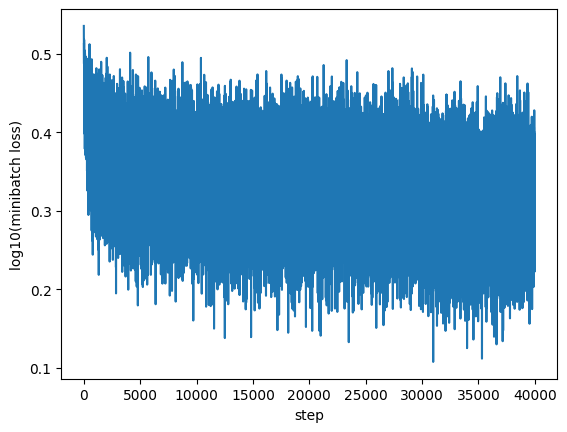

MLP train loss: 2.072
MLP dev   loss: 2.150
BIGRAM                MLP                   
---------------------------------------------
güsran                cangülü               
mmuslbi               mefkize               
te                    top                   
ören                  akayan                
yhimur                cemşuy                
öz                    güner                 
ulgüze                ersevcunzevi          
t                     havetdinçlit          
iyimenury             sertuthetdin          
beraceh               birakan               

Bigram Dev Loss:    2.491
MLP Train Loss:     2.072
MLP Dev Loss:       2.150
listede zaten olan -> bigram: 2 /10   mlp: 1 /10


In [ ]:

# # TASK 7 — Türkçe isimler: MLP vs Bigram

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

# 1) Türkçe dataset  encoding
words = open('turkce_isim_clean.txt', 'r', encoding='utf-8').read().splitlines()
print('isim sayısı:', len(words))                        # 13865
print(words[:8])

# 2) vocabulary — Türkçe alfabe 29 harf + "." = 30
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)
print('vocab_size:', vocab_size)
print(itos)

# 3) split — dosya ALFABETİK sıralı, karıştırmadan bölersen dev'e sadece t-z ile başlayan isimler düşer
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
train_words, dev_words, test_words = words[:n1], words[n1:n2], words[n2:]
print('train/dev/test isim:', len(train_words), len(dev_words), len(test_words))   # 11092 / 1386 / 1387

# 4) MLP dataset'i
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

Xtr,  Ytr  = build_dataset(train_words)
Xdev, Ydev = build_dataset(dev_words)
Xte,  Yte  = build_dataset(test_words)
print(Xtr.shape, Xdev.shape, Xte.shape)                 # (79958,3) (9893,3) (10022,3)


_ctx = [0] * block_size
for ch in 'emre.':
    print(''.join(itos[i] for i in _ctx), '--->', ch)
    _ctx = _ctx[1:] + [stoi[ch]]


# 5-9) model + Task 5'teki iyi initialization
emb_dim  = 10
n_hidden = 100
fan_in   = block_size * emb_dim                        # 30
gain     = 5 / 3                                       # tanh
w1_scale = gain / fan_in ** 0.5                        # ≈ 0.304

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, emb_dim),  generator=g)              # 30 x 10
W1 = torch.randn((fan_in, n_hidden),     generator=g) * w1_scale   # Kaiming: hpreact ~ N(0, 5/3) -> tanh doymaz
b1 = torch.zeros(n_hidden)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01       # logits ≈ 0 -> softmax emin değil
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
print('parametre sayısı:', sum(p.nelement() for p in parameters))  # 300 + 3000 + 100 + 3000 + 30 = 6430

def forward(params, X):
    C, W1, b1, W2, b2 = params
    emb = C[X]                                          # (B, 3, 10)
    embcat = emb.view(emb.shape[0], -1)                 # (B, 30)
    h = torch.tanh(embcat @ W1 + b1)                    # (B, 100)
    return h @ W2 + b2                                  # logits (B, 30)

@torch.no_grad()
def split_loss(params, X, Y):
    return F.cross_entropy(forward(params, X), Y).item()

# init sağlaması (Task 5'in dersi): başlangıç loss'u ≈ log(vocab_size) olmalı
print(f'başlangıç loss: {split_loss(parameters, Xtr, Ytr):.3f}   beklenen log({vocab_size}) = {torch.log(torch.tensor(float(vocab_size))):.3f}')

# 10-11) minibatch training + lr schedule
steps, batch_size = 40000, 32
lossi = []
for i in range(steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))  # A) random minibatch
    Xb, Yb = Xtr[ix], Ytr[ix]
    logits = forward(parameters, Xb)                    # B) forward
    loss = F.cross_entropy(logits, Yb)
    for p in parameters:
        p.grad = None                                   # C) zero grad
    loss.backward()                                     # D) backward
    lr = 0.1 if i < int(0.75 * steps) else 0.01         # 11) schedule: 0.1 -> 0.01
    for p in parameters:
        p.data += -lr * p.grad                          # E) update
    lossi.append(loss.log10().item())
    if i % 10000 == 0:
        print(f'{i:6d}/{steps}: {loss.item():.4f}')

plt.plot(lossi); plt.xlabel('step'); plt.ylabel('log10(minibatch loss)'); plt.show()

# 12-13) train / dev loss
mlp_train_loss = split_loss(parameters, Xtr, Ytr)
mlp_dev_loss   = split_loss(parameters, Xdev, Ydev)
print(f'MLP train loss: {mlp_train_loss:.3f}')
print(f'MLP dev   loss: {mlp_dev_loss:.3f}')
# Not: train set ~80k örnek, 40k x 32 = 1.28M -> ~16 epoch. İngilizceye göre küçük veri; train-dev farkı açılırsa overfit.

# 14) MLP ile Türkçe isim üret
@torch.no_grad()
def sample_mlp(params, n=10, seed=2147483647 + 10):
    g = torch.Generator().manual_seed(seed)
    names = []
    for _ in range(n):
        out, context = [], [0] * block_size
        while True:
            logits = forward(params, torch.tensor([context]))
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            if ix == 0:
                break
            out.append(itos[ix])
            context = context[1:] + [ix]
        names.append(''.join(out))
    return names

mlp_names = sample_mlp(parameters)

# 15) bigram — aynı train split, aynı dev split
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)
for w in train_words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1
P = (N + 1).float()                                     # +1 smoothing: görülmemiş çiftlere 0 verme
P /= P.sum(1, keepdim=True)

nll, cnt = 0.0, 0
for w in dev_words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        nll += -P[stoi[ch1], stoi[ch2]].log().item(); cnt += 1
bigram_dev_loss = nll / cnt

g = torch.Generator().manual_seed(2147483647)
bigram_names = []
for _ in range(10):
    out, ix = [], 0
    while True:
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        out.append(itos[ix])
    bigram_names.append(''.join(out))

# 16) karşılaştırma
print('=' * 45)
print(f"{'BIGRAM':<22}{'MLP':<22}")
print('-' * 45)
for b, m in zip(bigram_names, mlp_names):
    print(f'{b:<22}{m:<22}')
print()
print(f'Bigram Dev Loss:    {bigram_dev_loss:.3f}')
print(f'MLP Train Loss:     {mlp_train_loss:.3f}')
print(f'MLP Dev Loss:       {mlp_dev_loss:.3f}')
print('=' * 45)

# gerçek isim mi kontrolü (üretilenlerin kaçı zaten listede var?)
all_names = set(words)
print('listede zaten olan -> bigram:', sum(n in all_names for n in bigram_names), '/10   mlp:', sum(n in all_names for n in mlp_names), '/10')

